### DAPT: masked-idiom test

The intrinsic check on domain adaptation: top-5 fill-mask on Gambacorta et
al.'s 100 central-bank idioms (they report RoBERTa-base = 60/100,
CB-LMs ~90/100).

Reads `idioms.csv` from Drive, writes `dapt_idioms.png`.

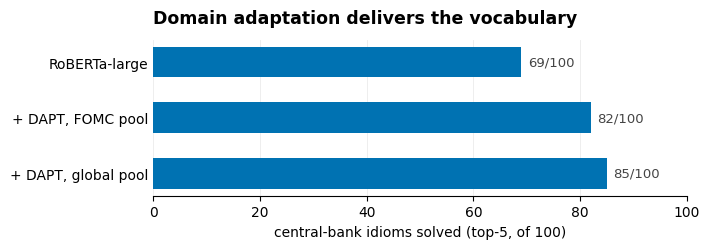

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import polars as pl

idi = pl.read_csv(RESULTS_DIR / "idioms.csv")

ROWS = [
    ("RoBERTa-large", "roberta-large"),
    ("+ DAPT, FOMC pool", "dapt-fomc:roberta-large"),
    ("+ DAPT, global pool", "dapt-global:roberta-large"),
]


def score(model):
    s = idi.filter(pl.col("model") == model)
    return s["hit"].sum()


fig, ax = plt.subplots(figsize=(7.2, 2.6))

ys = range(len(ROWS) - 1, -1, -1)
vals = [score(m) for _, m in ROWS]
ax.barh(list(ys), vals, height=0.55, color="#0072B2")
for y, v in zip(ys, vals):
    ax.text(v + 1.2, y, f"{v}/100", va="center", fontsize=9.5, color="#444")

ax.set_yticks(range(len(ROWS)))
ax.set_yticklabels([r[0] for r in reversed(ROWS)], fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel("central-bank idioms solved (top-5, of 100)", fontsize=10)

for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_axisbelow(True)

ax.set_title(
    "Domain adaptation delivers the vocabulary",
    fontsize=12.5,
    fontweight="bold",
    loc="left",
    pad=12,
)

fig.tight_layout()
fig.savefig("dapt_idioms.png", dpi=200, bbox_inches="tight", facecolor="white")

### What it shows

- One epoch of DAPT lifts RoBERTa-large from 69 to 82 (FOMC pool) / 85
  (global pool) of 100 idioms, with no idiom lost.
- Adaptation demonstrably delivered the vocabulary; whether it helps
  classification is the next figure's question.
- The mined 30-idiom FOMC-register list (53% -> 93% / 90%) stays in
  idioms.csv for the text; the figure sticks to the published external list.